# Post-Anomaly Detection Inference for Deep SVDD

This example shows how to perform selective inference for Deep Support Vector Data Description (Deep SVDD) on tabular data using the `pythonsi` library. The method computes statistically valid $p$-values to control the False Positive Rate (FPR) in a post-hoc manner. The implementation is based on the work by Thanh et al. (2026) [1].


### Reference
[1] Thanh, C. L. C., Vinh, D. Q., & Duy, V. N. L. (2026). Post-Anomaly Detection Inference for Deep SVDD. *arXiv preprint arXiv:2609.37935*.


In [ ]:
import sys
from pathlib import Path

import numpy as np
import torch



from pythonsi import Data, Pipeline
from pythonsi.anomaly_detection import DeepSVDDAD
from pythonsi.test_statistics import DeepSVDDTestStatistic
from network import MLP

In [ ]:
SEED = 42
N_FEATURES = 50
N_REFS = 20
ALPHA = 0.05

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

## 1. Load Trained Model

In [ ]:
ckpt = torch.load("weights/mlp_encoder.pth", map_location=DEVICE, weights_only=False)
cfg = ckpt["config"]

model = MLP(
    n_features=cfg["n_features"],
    hidden_dim=cfg["hidden_dim"],
    repdim=cfg["repdim"],
).to(DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

center_c = ckpt["center_c"]
R_squared = ckpt["R_squared"] *0.7
print(f"R² = {R_squared:.10f}")

R² = 0.2253899843


## 2. Generate Test & Reference Data

In [ ]:
rng = np.random.default_rng(SEED)

# Reference data: normal N(0,1)
X_refs = rng.normal(size=(N_REFS, N_FEATURES)).astype(np.float64)

# Test data: anomalous (shifted mean)
X_test = rng.normal(size=(1, N_FEATURES)).astype(np.float64)


# Check if test triggers anomaly
with torch.no_grad():
    feat = model(torch.from_numpy(X_test).float().to(DEVICE))
    score = torch.sum((feat - torch.tensor(center_c, device=DEVICE)) ** 2).item()

print(f"Score:  {score:.10f}")
print(f"R²:     {R_squared:.10f}")
print(f"Anomaly detected: {score > R_squared}")

Score:  0.2512427270
R²:     0.2253899843
Anomaly detected: True


## 3. Build Pipeline & Compute Selective p-value

In [ ]:
test_node = Data()
refs_node = Data()

detector = DeepSVDDAD(
    model=model,
    R_squared=R_squared,
    center=center_c,
    device="cpu",
    network_type="dnn",
)
anomaly_node = detector.run(test_node)

pipeline = Pipeline(
    inputs=(test_node, refs_node),
    output=anomaly_node,
    test_statistic=DeepSVDDTestStatistic(test_node, refs_node),
)

print("Running selective inference …")
anomalies, p_values = pipeline(
    inputs=[X_test, X_refs],
    covariances=[np.eye(N_FEATURES)],
    verbose=False,
)

print(f"\nDetected anomalies: {anomalies}")
print(f"Selective p-values: {p_values}")

if len(p_values) > 0 and p_values[0] is not None:
    print(f"Reject H₀ at α={ALPHA}? {'YES' if p_values[0] < ALPHA else 'NO'}")

Running selective inference …

Detected anomalies: [0]
Selective p-values: [0.4653421467192822]
Reject H₀ at α=0.05? NO


Plot the p-values

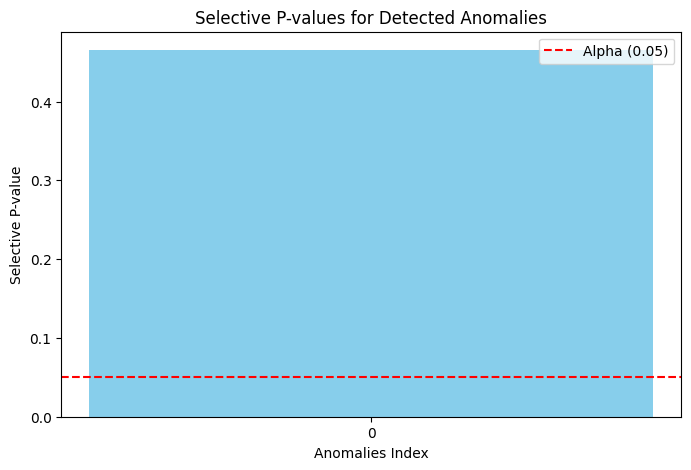

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar([str(anomaly) for anomaly in anomalies], p_values, color='skyblue')


plt.axhline(y=0.05, color='red', linestyle='--', label='Alpha (0.05)')

plt.xlabel("Anomalies Index")
plt.ylabel("Selective P-value")
plt.title("Selective P-values for Detected Anomalies")
plt.legend()
plt.show()
